<a href="https://colab.research.google.com/github/Tanupanchal26/VLAUE_ADDED-COURSE/blob/main/TASK_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np

data = {
    "Name": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K"],
    "Age": [22, np.nan, 24, 35, 28, np.nan, 40, 19, 30, 25, np.nan],
    "Fare": [100, 200, 1500, 300, 400, 5000, 600, 700, 800, 900, 10000],
    "Gender": ["male", "female", "female", "male", "male", "female", "male", "female", "male", "female", "male"],
    "Survived": [1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
print(df)


   Name   Age   Fare  Gender  Survived
0     A  22.0    100    male         1
1     B   NaN    200  female         0
2     C  24.0   1500  female         1
3     D  35.0    300    male         0
4     E  28.0    400    male         1
5     F   NaN   5000  female         0
6     G  40.0    600    male         1
7     H  19.0    700  female         1
8     I  30.0    800    male         0
9     J  25.0    900  female         1
10    K   NaN  10000    male         0


In [41]:
df.head()

,Name,Age,Fare,Gender,Survived
0,A,22.0,100,male,1
1,B,NaN,200,female,0
2,C,24.0,1500,female,1
3,D,35.0,300,male,0
4,E,28.0,400,male,1


In [42]:
df.tail()

,Name,Age,Fare,Gender,Survived
6,G,40.0,600,male,1
7,H,19.0,700,female,1
8,I,30.0,800,male,0
9,J,25.0,900,female,1
10,K,NaN,10000,male,0


In [43]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      11 non-null     object 
 1   Age       8 non-null      float64
 2   Fare      11 non-null     int64  
 3   Gender    11 non-null     object 
 4   Survived  11 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 572.0+ bytes


,Age,Fare,Survived
count,8.000000,11.000000,11.000000
mean,27.875000,1863.636364,0.545455
std,6.957781,3027.300027,0.522233
min,19.000000,100.000000,0.000000
25%,23.500000,350.000000,0.000000
50%,26.500000,700.000000,1.000000
75%,31.250000,1200.000000,1.000000
max,40.000000,10000.000000,1.000000


In [44]:
df.isnull().sum()

,0
Name,0
Age,3
Fare,0
Gender,0
Survived,0


In [45]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

/tmp/ipykernel_175/1809399462.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [46]:
df.duplicated().sum()


np.int64(0)

In [47]:
df.drop_duplicates(inplace=True)

In [48]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [49]:
df[(df["Fare"] < lower) | (df["Fare"] > upper)]

,Name,Age,Fare,Gender,Survived
5,F,27.875,5000,female,0
10,K,27.875,10000,male,0


In [50]:
df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

In [51]:
df.columns

Index(['Name', 'Age', 'Fare', 'Gender', 'Survived'], dtype='object')

In [52]:
df.loc[0:3, ["Name", "Age", "Fare"]]

,Name,Age,Fare
0,A,22.000,100
1,B,27.875,200
2,C,24.000,1500
3,D,35.000,300


In [53]:
df[df["Fare"] > 300]

,Name,Age,Fare,Gender,Survived
2,C,24.0,1500,female,1
4,E,28.0,400,male,1
6,G,40.0,600,male,1
7,H,19.0,700,female,1
8,I,30.0,800,male,0
9,J,25.0,900,female,1


In [54]:
pd.crosstab(df["Gender"], df["Survived"])

Survived,0,1
Gender,,
female,1,3
male,2,3


<Axes: >

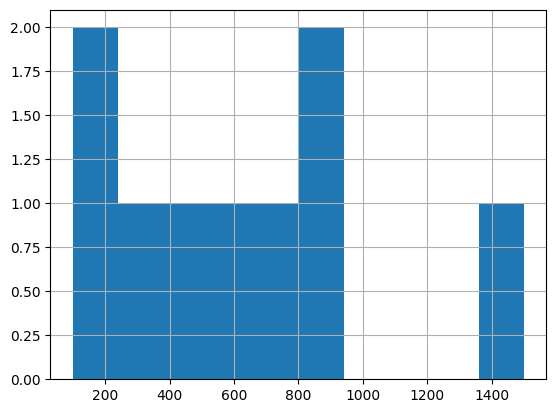

In [55]:
df["Fare"].hist()

In [58]:
df.to_csv("Titanic .csv", index=False)



## 1. NULL VALUES

* Missing data
* Check → `isnull().sum()`
* Handle →

  * `fillna()` (mean/median/0)
  * `dropna()`

---

## 2. DUPLICATE VALUES

* Repeated rows
* Check → `duplicated().sum()`
* Remove → `drop_duplicates()`

---

## 3. OUTLIERS

* Extreme values

### IQR Method:

* IQR = Q3 - Q1
* Lower = Q1 - 1.5×IQR
* Upper = Q3 + 1.5×IQR

### Handle:

* Remove → filtering
* Replace → `clip()`

---

# FINAL FORMULA

👉 `isnull → fillna`
👉 `duplicated → drop_duplicates`
👉 `IQR → remove/clip`

---

#  KEY POINT

✔ Clean data = better results
✔ Always check data first

---
